# RC Filter Analysis and Design Toolkit

**Author:** Vanessa Knight

## Objective

This notebook demonstrates how Python can be used as an engineering tool to analyze and design first-order RC low-pass filters.

Throughout this project we will:

- Calculate cutoff frequencies
- Visualize frequency response
- Design RC filters from specifications
- Verify engineering calculations
- Build interactive engineering tools using Jupyter widgets

## Engineering Background

A first-order RC low-pass filter allows low-frequency signals to pass while attenuating higher-frequency signals.

The cutoff frequency is defined by

$$
f_c=\frac{1}{2\pi RC}
$$

At the cutoff frequency, the filter gain equals

$$
|H(f_c)|=\frac{1}{\sqrt{2}}\approx0.707
$$

which corresponds to the famous **−3 dB point** used throughout electrical engineering.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact

# Engineering Functions

Instead of rewriting equations throughout the notebook, each engineering relationship is implemented once as a reusable Python function.

This approach makes the notebook:

- Easier to read
- Easier to debug
- Easier to maintain
- Easier to reuse in future engineering projects

In [28]:
# All Functions here

def cutoff_frequency(R, C):
    """
    Calculate the cutoff frequency of a first-order RC low-pass filter.

    Parameters
    
    R : float
        Resistance in Ohms.
    C : float
        Capacitance in Farads.

    Returns
    
    float
        Cutoff frequency in Hertz.
    """
    return 1 / (2 * np.pi * R * C)


def resistor_for_cutoff(fc, C):
    """
    Calculate the resistor required to achieve a desired cutoff frequency.

    Parameters
    
    fc : float
        Desired cutoff frequency in Hertz.
    C : float
        Capacitance in Farads.

    Returns
    
    float
        Required resistance in Ohms.
    """
    return 1 / (2 * np.pi * C * fc)


def frequency_response(f, R, C):
    """
    Calculate the magnitude response of a first-order RC low-pass filter.

    Parameters
    
    f : array_like
        Frequency values in Hertz.
    R : float
        Resistance in Ohms.
    C : float
        Capacitance in Farads.

    Returns
    
    array_like
        Magnitude response |H(f)|.
    """
    return 1 / np.sqrt(1 + (2 * np.pi * f * R * C) ** 2)

# Example 1 – Cutoff Frequency Calculation

Let's begin by verifying the cutoff frequency equation for a simple RC low-pass filter.

For this example:

- Resistance = 1000 Ω
- Capacitance = 1 µF

The theoretical cutoff frequency is calculated using

$$
f_c=\frac{1}{2\pi RC}
$$

We'll compare our result to the expected value of approximately **159.15 Hz**.

In [29]:
# Example 1: Calculate the cutoff frequency

R = 1000          # Ohms
C = 1e-6          # Farads (1 µF)

fc = cutoff_frequency(R, C)

print(f"Resistance: {R} Ω")
print(f"Capacitance: {C:.1e} F")
print(f"Cutoff Frequency: {fc:.2f} Hz")

Resistance: 1000 Ω
Capacitance: 1.0e-06 F
Cutoff Frequency: 159.15 Hz


# Frequency Response Analysis

A single cutoff frequency does not fully describe a filter.

To understand how the circuit behaves across many frequencies, we compute the magnitude response

$$
|H(f)|=\frac{1}{\sqrt{1+\left(2\pi fRC\right)^2}}
$$

This section visualizes how the filter attenuates higher-frequency signals while allowing lower-frequency signals to pass.

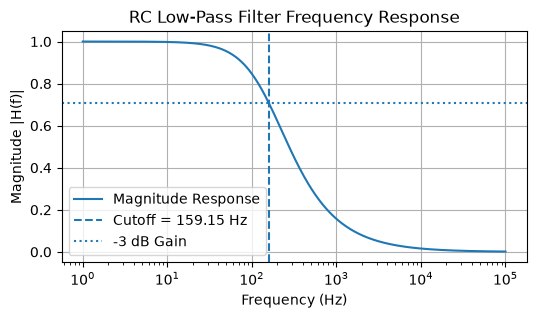

In [30]:
# Frequency response of the RC low-pass filter

f = np.logspace(0, 5, 500)

H = frequency_response(f, R, C)

plt.figure(figsize=(6, 3))

plt.semilogx(f, H, label="Magnitude Response")

plt.axvline(fc, linestyle="--", label=f"Cutoff = {fc:.2f} Hz")
plt.axhline(1 / np.sqrt(2), linestyle=":", label="-3 dB Gain")

plt.title("RC Low-Pass Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude |H(f)|")

plt.grid(True)
plt.legend()

plt.show()

# Interactive Filter Analysis

Rather than editing code for every new circuit, Jupyter widgets allow us to interactively explore how changing component values affects the frequency response.

Move the sliders to observe how the cutoff frequency shifts as the resistance and capacitance change.

In [ ]:
@interact(
    R=(100, 10000, 100),
    C=(0.1e-6, 2e-6, 0.1e-6)
)
def analyze_filter(R, C):

    fc = cutoff_frequency(R, C)

    f = np.logspace(0, 5, 500)

    H = frequency_response(f, R, C)

    plt.figure(figsize=(6,3))

    plt.semilogx(f, H, linewidth=2)

    plt.axvline(fc,
                linestyle="--",
                label=f"Cutoff = {fc:.2f} Hz")

    plt.axhline(1/np.sqrt(2),
                linestyle=":",
                label="-3 dB Gain")

    plt.title("Interactive RC Low-Pass Filter Analysis")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude |H(f)|")

    plt.grid(True)

    plt.legend()

    plt.show()

    print(f"Resistance: {R} Ω")
    print(f"Capacitance: {C:.7f} F")
    print(f"Cutoff Frequency: {fc:.2f} Hz")

interactive(children=(IntSlider(value=5000, description='R', max=10000, min=100, step=100), FloatSlider(value=…

# Interactive Filter Design

In many engineering problems, the desired cutoff frequency is known before the component values are selected.

This tool computes the required resistor value for a specified cutoff frequency and capacitor value.

The resulting design is then verified and visualized using the filter's frequency response.

In [ ]:
@interact(
    fc=(100, 5000, 50),
    C=(0.1e-6, 2e-6, 0.1e-6)
)
def design_filter(fc, C):

    # Design the resistor
    R = resistor_for_cutoff(fc, C)

    # Verify the design
    verified_fc = cutoff_frequency(R, C)

    # Frequency axis
    f = np.logspace(0, 5, 500)

    # Frequency response
    H = frequency_response(f, R, C)

    plt.figure(figsize=(6,3))

    plt.semilogx(f, H, linewidth=2)

    plt.axvline(fc,
                linestyle="--",
                label=f"Cutoff = {fc:.2f} Hz")

    plt.axhline(1/np.sqrt(2),
                linestyle=":",
                label="-3 dB Gain")

    plt.scatter(fc,
                1/np.sqrt(2),
                label="Cutoff Point")

    plt.title("RC Filter Design Verification")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude |H(f)|")

    plt.grid(True)

    plt.legend()

    plt.show()

    print(f"Desired Cutoff Frequency : {fc:.2f} Hz")
    print(f"Capacitance              : {C:.7f} F")
    print(f"Required Resistance      : {R:.2f} Ω")
    print(f"Verified Cutoff Frequency: {verified_fc:.2f} Hz")
    print(f"RC Time Constant         : {R*C:.3e} s")

interactive(children=(IntSlider(value=2550, description='fc', max=5000, min=100, step=50), FloatSlider(value=1…

# Conclusions

This project demonstrates how Python can be used to solve practical electrical engineering problems.

### Skills Demonstrated

- Python programming
- NumPy numerical computing
- Matplotlib visualization
- Interactive Jupyter widgets
- RC filter analysis
- RC filter design
- Engineering verification
- Scientific documentation

### Future Improvements

Possible extensions include:

- High-pass filters
- Band-pass filters
- Second-order filters
- Bode magnitude (dB) plots
- Phase response
- Automatic selection of standard resistor values (E12/E24)